# Taiwan equities: is the market granular enough to estimate a demand multiplier?

Exploratory pass before attempting the Gabaix–Koijen granular-IV estimate
(NBER [w28204](https://www.nber.org/papers/w28204), [w28967](https://www.nber.org/papers/w28967)).

**The question the GIV answers.** If institutions push TWD 1 into Taiwanese
equities, how much does aggregate market value rise? Gabaix & Koijen find about
$5 for the US — a demand elasticity near 0.2, roughly 100× more inelastic than
standard models predict. Nobody has estimated it for Taiwan.

**Why Taiwan.** GIV needs *granularity*: a few players large enough that their
idiosyncratic shocks move the aggregate. The relevant statistic is the
Herfindahl \(H=\sum_i S_i^2\); power scales with it, since
\(\mathrm{var}(u_S)=H\sigma_u^2\). TAIEX is cap-weighted on total issued shares
and TSMC alone is over 40% of it.

**What this notebook decides.** Six go/no-go checks, in order:

1. Data coverage — is the panel complete enough?
2. Granularity — is `1/H` small enough for the instrument to have power?
3. The flow variable — is `dq` well behaved, or driven by outliers?
4. Market clearing — do the observed sectors span the market?
5. Factor structure — how much flow variation is idiosyncratic rather than common?
6. Instrument strength — does `Z` actually move the index, and is the first stage strong?

Only if all six pass is the structural estimate worth running.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import panel as P
import giv as G

pd.set_option("display.width", 120)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True,
                     "grid.alpha": .3, "font.size": 10})

## 1. Data coverage

**What this does.** Loads whatever `collect_twse.py` has written and reports the
shape of the panel: date range, stocks per day, and how complete the flow data
is relative to the price data. Safe to run mid-pull — it just reports a shorter
sample.

Source is TWSE directly: `T86` (三大法人買賣超日報) for per-stock institutional
buy/sell in shares, `MI_INDEX` (每日收盤行情) for prices, `t187ap03_L` for shares
issued. Universe is the top 300 by market cap; the full ~1,000 listed common
stocks are pulled and used for factor extraction.

panel   446,358 stock-days
dates   2020-03-03 .. 2026-09-23  (1600 trading days)
stocks  299 in panel, 300 in universe


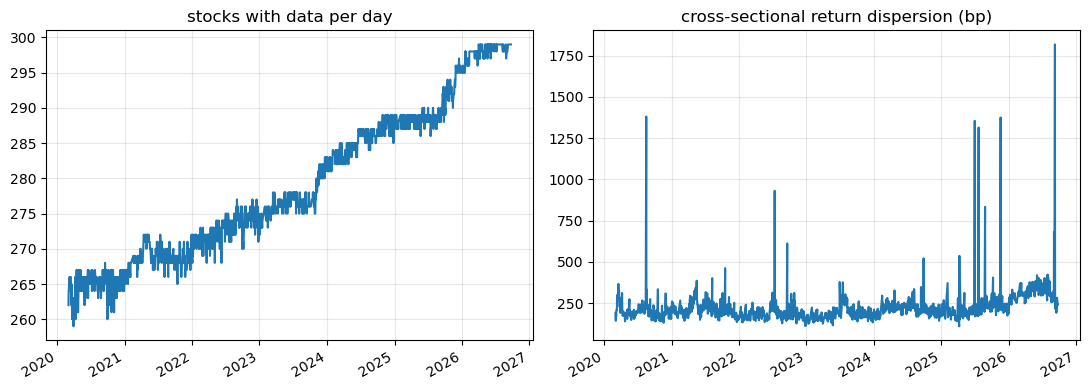

In [2]:
df  = P.build_panel()
uni = P.load_universe()
ids = uni.stock_id.tolist()

print(f"panel   {len(df):,} stock-days")
print(f"dates   {df.date.min().date()} .. {df.date.max().date()}  ({df.date.nunique()} trading days)")
print(f"stocks  {df.stock_id.nunique()} in panel, {len(ids)} in universe")

cov = df.groupby("date").stock_id.nunique()
fig, ax = plt.subplots(1, 2)
cov.plot(ax=ax[0], title="stocks with data per day")
ax[0].set_xlabel("")
df.groupby("date").ret.std().mul(1e4).plot(ax=ax[1], title="cross-sectional return dispersion (bp)")
ax[1].set_xlabel("")
plt.tight_layout()

## 2. Granularity — does the instrument have any power?

**What this does.** Computes the Herfindahl of index weights each day and plots
`1/H`, the effective number of independent units, alongside TSMC's weight.

**The bar.** GIV power comes from `var(u_S) = H·σ²_u`. A market where `1/H` is in
the hundreds (the US) gives a weak instrument; single digits is a laboratory.
For reference, the 5-sector aggregate flow file used in the Gotobi pitch gives
`1/H = 2.07` — too concentrated in a *different* sense, since one sector at 84%
of flow means the wedge collapses onto that sector's raw flow.

**Note that `1/H` is strongly time-varying.** TSMC's index weight roughly
doubled over the sample, so the market was materially less granular in 2020 than
it is now. Read the series, not the average — and expect the instrument to be
weaker in the early sample.

1/H  mean 9.13   min 4.40   max 16.15
TSMC weight  mean 33.4%   latest 43.0%

top 10 weights, latest day:
stock_id
2330    42.97
2454     5.52
2308     3.27
2317     2.39
3711     2.05
2881     1.42
2303     1.33
3037     1.26
1303     1.20
2383     1.19


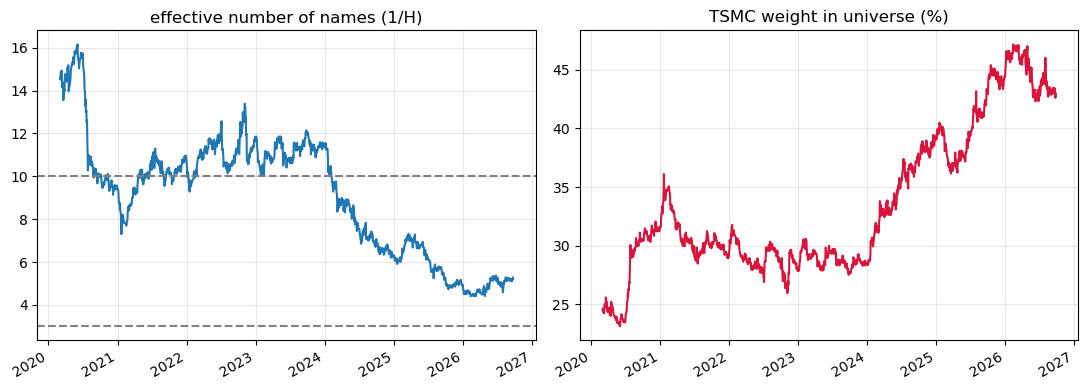

In [3]:
w  = P.weight_matrix(df, ids)
hh = P.herfindahl(w)

fig, ax = plt.subplots(1, 2)
hh.eff_n.plot(ax=ax[0], title="effective number of names (1/H)")
ax[0].axhline(10, ls="--", c="grey"); ax[0].axhline(3, ls="--", c="grey")
ax[0].set_xlabel("")
w["2330"].mul(100).plot(ax=ax[1], title="TSMC weight in universe (%)", color="crimson")
ax[1].set_xlabel("")
plt.tight_layout()

print(f"1/H  mean {hh.eff_n.mean():.2f}   min {hh.eff_n.min():.2f}   max {hh.eff_n.max():.2f}")
print(f"TSMC weight  mean {w['2330'].mean():.1%}   latest {w['2330'].iloc[-1]:.1%}")
print()
print("top 10 weights, latest day:")
print((w.iloc[-1].nlargest(10) * 100).round(2).to_string())

## 3. The flow variable

**What this does.** `dq_it` is institutional net buying in stock *i* as a
fraction of shares outstanding, in basis points — the stock-level analogue of
Gabaix–Koijen's change in equity holdings. Here we check its distribution,
its tails, and its persistence.

**Why persistence matters.** The paper is explicit that what you actually
measure is `ζ_M = ζ + κφ_f + ζ_C`, contaminated by the speed at which flows
mean-revert (`φ_f`) and by corporate supply elasticity (`ζ_C`, buybacks and
issuance). If `dq` is strongly autocorrelated, `κφ_f` is not negligible and the
estimate needs that caveat attached.

dq distribution (bp of shares outstanding):


count    446358.00
mean          0.04
std          31.48
min       -1013.27
1%          -89.90
5%          -33.59
25%          -5.60
50%          -0.15
75%           4.81
95%          33.80
99%          98.05
max        1518.09


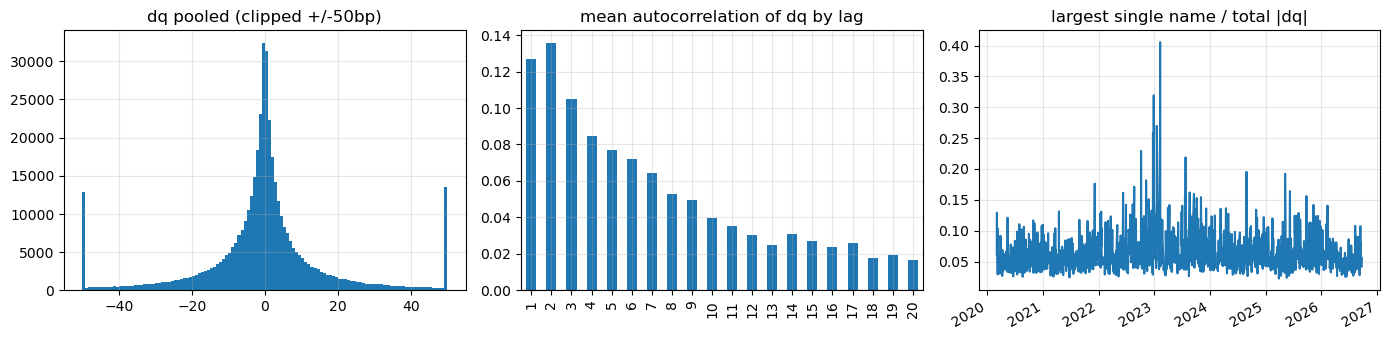

In [4]:
dq = P.to_wide(df, "dq", ids)

print("dq distribution (bp of shares outstanding):")
print(dq.stack().describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2).to_string())

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
dq.stack().clip(-50, 50).hist(bins=120, ax=ax[0])
ax[0].set_title("dq pooled (clipped +/-50bp)")

# Only names with enough history to have a meaningful autocorrelation.
dq_ac = dq.loc[:, dq.notna().sum() >= 30]
ac = pd.Series({k: dq_ac.apply(lambda s: s.dropna().autocorr(k)).mean()
                for k in range(1, 21)})
ac.plot.bar(ax=ax[1], title="mean autocorrelation of dq by lag")
ax[1].axhline(0, c="k", lw=.8)

# How much of total flow does the single largest name account for each day?
share_top = dq.abs().max(axis=1) / dq.abs().sum(axis=1)
share_top.plot(ax=ax[2], title="largest single name / total |dq|")
ax[2].set_xlabel("")
plt.tight_layout()

## 4. Market clearing — do these sectors span the market?

**What this does.** Sums the five reported institutional categories and compares
against total market turnover, to size the residual (retail plus untracked)
sector.

**Why this is the hard constraint.** The identity that delivers the multiplier
is market clearing, `Δq_St = 0` — every share bought is a share sold. The five
TWSE institutional categories do *not* span the market; Taiwanese retail is the
huge residual counterparty. Any macro-leg estimate has to construct that
residual explicitly. This section sizes the problem.

institutions are 7.6% of traded value on average
-> the remainder is the residual sector the macro leg must construct


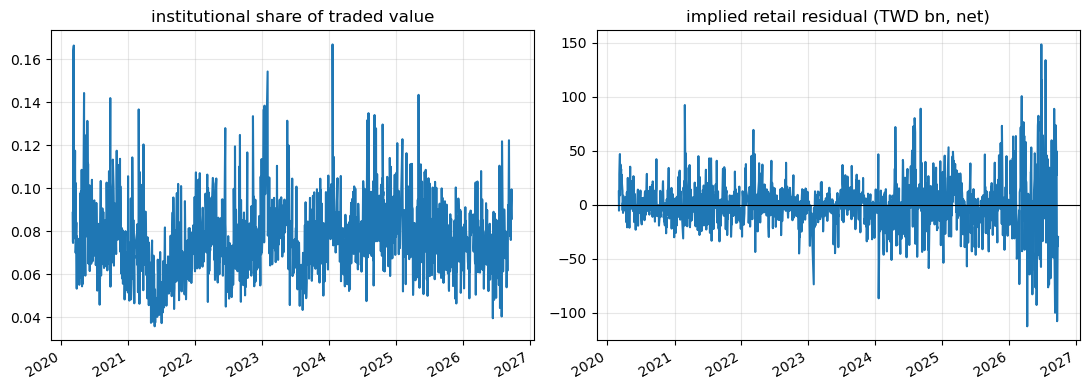

In [5]:
flow_cols = [c for c in df.columns if c.startswith("dq_") and c != "dq_S"]
by_cat = df.groupby("date")[[c for c in flow_cols]].apply(
    lambda g: g.mul(0).add(g.sum()).iloc[0])

gross = df.groupby("date").apply(
    lambda g: pd.Series({
        "inst_buy_value":  (g.inst_net.clip(lower=0) * g.close).sum(),
        "inst_sell_value": (-g.inst_net.clip(upper=0) * g.close).sum(),
        "market_value":    g.trade_value.sum(),
    }), include_groups=False)

gross["inst_share"] = (gross.inst_buy_value + gross.inst_sell_value) / (2 * gross.market_value)
gross["retail_residual"] = -(df.groupby("date").apply(
    lambda g: (g.inst_net * g.close).sum(), include_groups=False))

fig, ax = plt.subplots(1, 2)
gross.inst_share.plot(ax=ax[0], title="institutional share of traded value")
ax[0].set_xlabel("")
gross.retail_residual.div(1e9).plot(ax=ax[1], title="implied retail residual (TWD bn, net)")
ax[1].axhline(0, c="k", lw=.8); ax[1].set_xlabel("")
plt.tight_layout()

print(f"institutions are {gross.inst_share.mean():.1%} of traded value on average")
print("-> the remainder is the residual sector the macro leg must construct")

## 5. Factor structure — how much of flow is idiosyncratic?

**What this does.** Demeans `dq` cross-sectionally (which removes both the
common factor and the `−ζΔp_t` term), then runs PCA to extract `r` common
factors. Plots the scree and reports the share of variance left in the residual.

**Why this is the crux.** GIV is built from `u_it`, the idiosyncratic part. If
the first principal component eats most of the variance, there is little
idiosyncratic variation to instrument with and the whole exercise is
underpowered. We want a *flat* scree — lots of residual.

**The identifying assumption** is only `E[u_it η_t] = 0`. The main threat named
in the paper is an omitted factor whose loadings correlate with size
(`λ_S − λ_E ≠ 0`), which is why section 7 re-estimates across `r`.

PC1 explains 9.4% of demeaned flow variance
PC1-5 together 14.5%
residual (idiosyncratic) share 85.5%

loadings on PC1, most extreme names:
stock_id
3006    0.043
3035    0.040
2363    0.037
6282    0.036
2367    0.036
stock_id
2207   -0.172
5880   -0.171
2539   -0.166
2838   -0.162
6505   -0.160


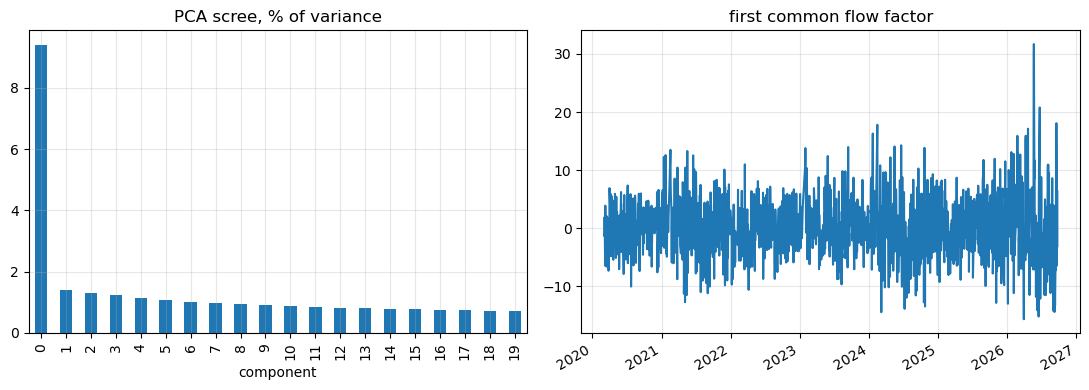

In [6]:
chk, centre = G.demean_cross_section(dq)
eta, loadings, var_ratio, u = G.extract_factors(chk, n_factors=5)

fig, ax = plt.subplots(1, 2)
var_ratio.head(20).mul(100).plot.bar(ax=ax[0], title="PCA scree, % of variance")
ax[0].set_xlabel("component")
eta.eta1.plot(ax=ax[1], title="first common flow factor")
ax[1].set_xlabel("")
plt.tight_layout()

print(f"PC1 explains {var_ratio.iloc[0]:.1%} of demeaned flow variance")
print(f"PC1-5 together {var_ratio.head(5).sum():.1%}")
print(f"residual (idiosyncratic) share {1 - var_ratio.head(5).sum():.1%}")
print()
print("loadings on PC1, most extreme names:")
print(loadings.eta1.nlargest(5).round(3).to_string())
print(loadings.eta1.nsmallest(5).round(3).to_string())

## 6. The instrument

**What this does.** Builds `Z_t = u_St − u_Et`, the size-weighted minus
quasi-equal-weighted average of the idiosyncratic flow shocks, and checks two
things: that it is not simply a relabelling of the raw aggregate flow, and that
it has a strong first stage against the index return.

**The failure mode to watch for.** On the 5-sector aggregate file this wedge had
`corr(Z, foreign flow) = 0.999` — the "instrument" was one sector's raw flow,
which is emphatically *not* exogenous. Here `Z` is built from PCA residuals, so
the common component is already projected out, but with TSMC above 40% the
size-weighted average is still close to TSMC alone. That is legitimate GIV — it
is exactly the "China in the oil market" case from the paper — but it must be
stated plainly rather than hidden, and it is what section 7's ex-TSMC re-run
tests.

corr(Z, raw size-weighted flow dq_S) = 0.527
corr(Z, equal-weighted flow dq_E)    = 0.051
corr(Z, PC1)                         = -0.032   <- should be ~0 by construction


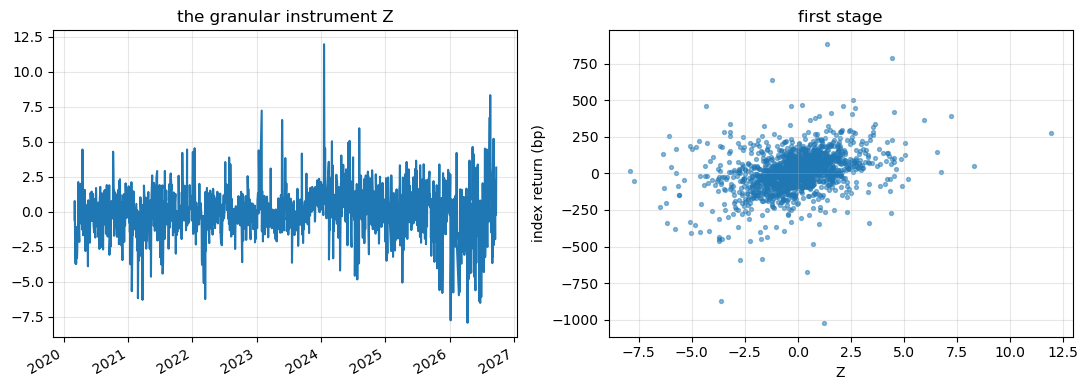

In [7]:
z  = G.build_giv(dq, w, u=u)
dp = P.index_return(df, ids)

print(f"corr(Z, raw size-weighted flow dq_S) = {z.Z.corr(z.dq_S):.3f}")
print(f"corr(Z, equal-weighted flow dq_E)    = {z.Z.corr(z.dq_E):.3f}")
print(f"corr(Z, PC1)                         = {z.Z.corr(eta.eta1):.3f}   <- should be ~0 by construction")

fig, ax = plt.subplots(1, 2)
z.Z.plot(ax=ax[0], title="the granular instrument Z"); ax[0].set_xlabel("")
d = pd.concat([z.Z, dp.rename("dp")], axis=1).dropna()
ax[1].scatter(d.Z, d.dp * 1e4, s=8, alpha=.5)
ax[1].set_xlabel("Z"); ax[1].set_ylabel("index return (bp)"); ax[1].set_title("first stage")
plt.tight_layout()

## 7. First-pass estimate, and how much the GIV moves the answer

**What this does.** Three numbers side by side:

- **naive OLS** of the index return on raw size-weighted flow — biased, because
  both sides load on `η_t`. This is the number the GIV exists to correct.
- **GIV**, equation (3): `Δp_t = M·Z_t + β'η_t + e_t`, reading `M` directly.
- **2SLS**, equation (4): `Δq_Et = −ζ·Δp_t + β'η_t + ε_t` with `Δp_t`
  instrumented by `Z_t`, reporting the first-stage F.

Then the robustness that matters most here: re-estimate across the number of
factors `r`, and re-estimate excluding TSMC. With TSMC above 40% of the index,
if `M` collapses without it then what we have is a TSMC multiplier, not a
Taiwan multiplier — a real finding either way, and one to report rather than
bury.

**Do not read the point estimate until the full sample has landed.** On a
partial panel this is a wiring check, not a result.

**Known problem with the 2SLS leg.** Equation (4) as written puts the
*equal-weighted* flow on the left and the *cap-weighted* index return on the
right. In Gabaix–Koijen the left-hand side is a sector's own demand and the
right-hand side is the return on what that sector holds; here the two sides are
weighted differently, and the first partial-sample run returns a negative `ζ`,
which is economically the wrong sign. Treat `M` from equation (3) as the live
estimate and the 2SLS number as not yet correctly specified — it needs the
left-hand side rebuilt as a holdings-weighted sector demand before it means
anything.

In [8]:
res_giv   = G.estimate_multiplier(dp, z.Z, controls=eta)
res_naive = G.naive_ols(dp, z.dq_S)
fit_2sls, fstat = G.estimate_elasticity(z.dq_E, dp, z.Z, controls=eta)

print(f"naive OLS   coef {res_naive.params['dq_S']: .5f}   t {res_naive.tvalues['dq_S']: .2f}")
print(f"GIV     M = {res_giv.params['Z']: .5f}   t {res_giv.tvalues['Z']: .2f}")
print(f"2SLS  zeta = {-fit_2sls.params['dp']: .5f}   first-stage F {fstat: .1f}")
print(f"          n = {int(res_giv.nobs)} days")

naive OLS   coef  0.00302   t  28.93
GIV     M =  0.00304   t  15.48
2SLS  zeta = -59.28406   first-stage F  490.4
          n = 1600 days


In [9]:
# Stability across the number of extracted factors -- the paper's own
# recommended check against omitted factors correlated with size.
rows = []
for r in range(1, 7):
    e_r, _, _, u_r = G.extract_factors(chk, n_factors=r)
    z_r = G.build_giv(dq, w, u=u_r)
    fit = G.estimate_multiplier(dp, z_r.Z, controls=e_r)
    rows.append({"r": r, "M": fit.params["Z"], "t": fit.tvalues["Z"]})
print(pd.DataFrame(rows).round(5).to_string(index=False))

 r       M        t
 1 0.00335 19.54239
 2 0.00329 20.57044
 3 0.00317 19.86002
 4 0.00300 15.40177
 5 0.00304 15.48375
 6 0.00290 14.39375


In [10]:
# Ex-TSMC. With 2330 above 40% of the index, this separates "Taiwan multiplier"
# from "TSMC multiplier".
ids_ex = [s for s in ids if s != "2330"]
df_ex  = df[df.stock_id != "2330"]
dq_ex  = P.to_wide(df_ex, "dq", ids_ex)
w_ex   = P.weight_matrix(df_ex, ids_ex)
dp_ex  = P.index_return(df_ex, ids_ex)

chk_ex, _ = G.demean_cross_section(dq_ex)
eta_ex, _, vr_ex, u_ex = G.extract_factors(chk_ex, n_factors=3)
z_ex = G.build_giv(dq_ex, w_ex, u=u_ex)
fit_ex = G.estimate_multiplier(dp_ex, z_ex.Z, controls=eta_ex)

print(f"1/H ex-TSMC          {1/(w_ex.iloc[-1]**2).sum():.2f}  (vs {1/(w.iloc[-1]**2).sum():.2f} with)")
print(f"M   ex-TSMC   {fit_ex.params['Z']: .5f}   t {fit_ex.tvalues['Z']: .2f}")
print(f"M   with TSMC {res_giv.params['Z']: .5f}   t {res_giv.tvalues['Z']: .2f}")

1/H ex-TSMC          43.19  (vs 5.20 with)
M   ex-TSMC    0.00232   t  16.07
M   with TSMC  0.00304   t  15.48


## 8. Data quality: unadjusted prices

**What this does.** TWSE closes are **not** adjusted for dividends or stock
dividends, so ex-days show up as large negative returns. `flag_ex_days` marks
the suspects using the fact that a mechanical price adjustment, unlike a real
selloff, is not accompanied by unusual volume.

Taiwan concentrates ex-dividend dates in July–September, so this contamination
is seasonal and could plausibly correlate with flow. Worth quantifying before
trusting anything.

**Proper fix:** TWSE's `TWT49U` (除權除息計算結果表) gives exact adjustment
factors. Until that is wired in, the check below is whether results survive
dropping the flagged days.

flagged 1,080 of 446,358 stock-days (0.24%)



M excluding flagged days  0.00316  t  20.25


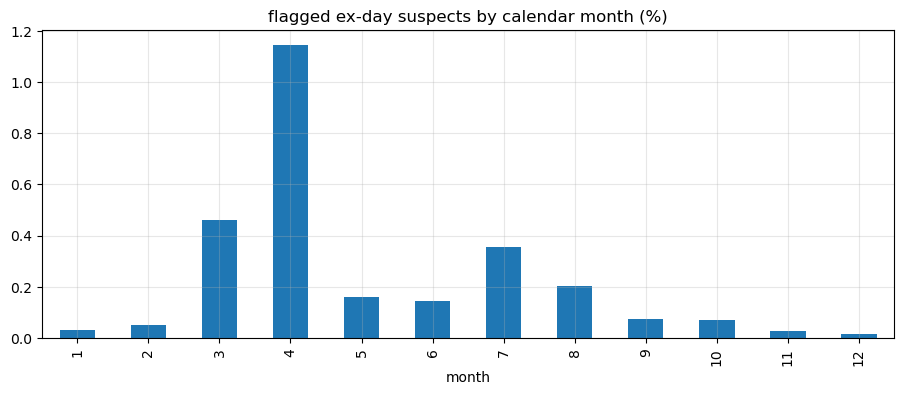

In [11]:
dfx = P.flag_ex_days(df)
print(f"flagged {dfx.ex_suspect.sum():,} of {len(dfx):,} stock-days "
      f"({dfx.ex_suspect.mean():.2%})")
by_month = dfx.groupby(dfx.date.dt.month).ex_suspect.mean().mul(100)
ax = by_month.plot.bar(title="flagged ex-day suspects by calendar month (%)")
ax.set_xlabel("month")

# Does dropping them change the first-pass estimate?
df_cl = dfx[~dfx.ex_suspect]
dq_cl = P.to_wide(df_cl, "dq", ids)
w_cl  = P.weight_matrix(df_cl, ids)
dp_cl = P.index_return(df_cl, ids)
chk_cl, _ = G.demean_cross_section(dq_cl)
eta_cl, _, _, u_cl = G.extract_factors(chk_cl, n_factors=3)
z_cl = G.build_giv(dq_cl, w_cl, u=u_cl)
fit_cl = G.estimate_multiplier(dp_cl, z_cl.Z, controls=eta_cl)
print(f"\nM excluding flagged days {fit_cl.params['Z']: .5f}  t {fit_cl.tvalues['Z']: .2f}")

## Checklist

Fill in once the full sample has landed. The estimate is only worth writing up
if the first six all pass.

| # | Check | Bar | Result |
|---|-------|-----|--------|
| 1 | Coverage | ~1,600 trading days, ~1,000 stocks/day | |
| 2 | Granularity | `1/H` in single digits | |
| 3 | Flow variable | not driven by a handful of outlier days | |
| 4 | Market clearing | residual sector sized and constructible | |
| 5 | Factor structure | idiosyncratic share large; flat scree | |
| 6 | Instrument | first-stage F > 10; `Z` not a relabelled raw flow | |
| 7 | Stability in `r` | `M` flat across 1–6 factors | |
| 8 | Ex-TSMC | `M` survives, or the TSMC dependence is the finding | |
| 9 | Ex-day contamination | `M` unchanged dropping flagged days | |

**Next steps regardless of outcome**

- Backfill weekly shares issued (`build_shares_history.py`) so 2020 weights stop
  using 2026 share counts.
- Wire `TWT49U` adjustment factors for genuinely adjusted returns.
- Add the macro leg: construct the retail residual so sectors sum to market
  clearing, then estimate the *sector-level* multiplier and compare with the
  stock-level one. That micro-versus-macro wedge is the actual pitch.